## Actividad 2: Regresión Lineal

### Exploración y contextualización de los datos



Para este porblema, tenemos una lista de los 142 paises analizados por el World Happiness Report en el 2012. Aqui tenemos, organizados por feicidad promedio calculada, a los paises con su respectivo PIB. La escala de la felicidad va del 1-8, donde 1 es lo mas infeliz posible, mientras que 8 es lo mas feliz posible.

Se esperaria que los paises con mayor felicidad promedio sean los que tienen un PIB ayor, ya que el dinero puede facilitar la vida y eliminar preocupaciones. Habiendo dicho esto, es imposible atribuir la felicidad de cualquier persona, por no decir todo un pais, a una sola variable.

In [ ]:
import pandas as pd
datos=pd.read_csv("/content/drive/MyDrive/Colab Notebooks/A1_2_Felicidad_y_GDP.csv")
datosPib=pd.read_csv("/content/drive/MyDrive/Colab Notebooks/PIB_Per_Capita_2023_2024.csv")
datosLE=pd.read_csv("/content/drive/MyDrive/Colab Notebooks/LifeExpectancy2024.csv")
datosCPI=pd.read_csv("/content/drive/MyDrive/Colab Notebooks/CPI2024.csv")
print(datos.head())
print(datosPib.head())
print(datosLE.head())
print(datosCPI.head())

          Pais  Felicidad           GDP
0      Finland     7.8210  2.718370e+11
1      Denmark     7.6362  3.560850e+11
2      Iceland     7.5575  2.171808e+10
3  Switzerland     7.5116  7.522480e+11
4  Netherlands     7.4149  9.138650e+11
                  Country Name Country Code                Indicator Name  \
0                        Aruba          ABW  GDP per capita (current US$)   
1  Africa Eastern and Southern          AFE  GDP per capita (current US$)   
2                  Afghanistan          AFG  GDP per capita (current US$)   
3   Africa Western and Central          AFW  GDP per capita (current US$)   
4                       Angola          AGO  GDP per capita (current US$)   

   Indicator Code          2023          2024  
0  NY.GDP.PCAP.CD  35718.753120  39498.594130  
1  NY.GDP.PCAP.CD   1571.449189   1615.396356  
2  NY.GDP.PCAP.CD    413.757895           NaN  
3  NY.GDP.PCAP.CD   1841.855064   1411.337029  
4  NY.GDP.PCAP.CD   2916.136633   2665.874448  
         

### Modelo de regresión lineal simple


Para empezar a analizar nuestros datos, escogeremos el PIB de cualquier pais como la variable explicativa. Esto es porque esperariamos que se pudiera cambiar la felicidad de las personas conforme cambie el ingreso promedio del pais.

Como se pueden observar los resultados a continuacion, nuestro valor de Prob (F-statistic) = 0.0412. Como este valor es menor a 0.05, podemos asumir que hay una relacion estadisticamente significativa, pero tambien podemos ver como nuestro valor de R2 es de 0.3, lo cual significa que la relacion noes fuerte, y que el GDP no explica bien el comporamiento de la felicidad a traves de diferentes paises por si sola.

                            OLS Regression Results                            
Dep. Variable:              Felicidad   R-squared:                       0.030
Model:                            OLS   Adj. R-squared:                  0.023
Method:                 Least Squares   F-statistic:                     4.246
Date:                Mon, 26 Jan 2026   Prob (F-statistic):             0.0412
Time:                        16:57:04   Log-Likelihood:                -210.63
No. Observations:                 141   AIC:                             425.3
Df Residuals:                     139   BIC:                             431.2
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          5.5099      0.095     58.247      0.0

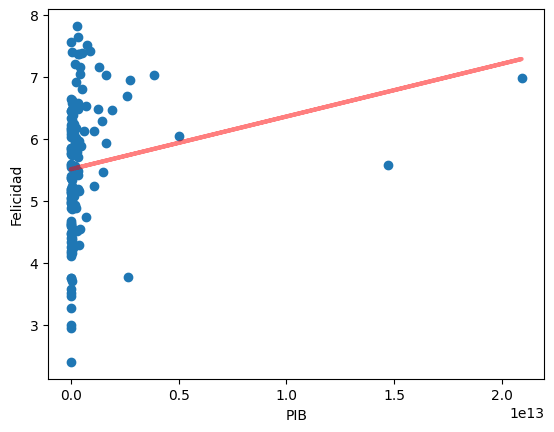

In [ ]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
x = datos.GDP
y = datos.Felicidad

import statsmodels.api as sm
model = sm.OLS(y,sm.add_constant(x))
results = model.fit()
print(results.summary())

plt.scatter(x, y)
plt.ylabel("Felicidad")
plt.xlabel("PIB")
yHat = 5.5099 + 8.509e-14*x
plt.plot(x, yHat, c = "r", linewidth = 3, alpha = 0.5)
plt.show()

Para la extension del conjunto de datos, escoji por fines practicos tres metricas que considere importante basado en una busqueda sencilla. Estas tres son la esperanza de vida promedio, el PIB por capita, y el indice de corrupcion percibida de cada pais. Utilice de fuentes la OMS, The World Bank, y Transprency International, las cuales se consideran como fuentes confiables, con datos recientes (del 2024).

No todas estas bases de datos tienen los mismos paises, ya que unas tiene mas que otros, por lo tanto se eliminaran los paises que con los que no se encuentre la informacion completa, por lo que nuestro tamano de muestra seria menor que el de antes.

In [ ]:
merged = datos.merge(datosCPI, left_on="Pais", right_on="Country", how="inner")
merged = merged.merge(datosLE, left_on="Pais", right_on="Location", how="inner")
merged = merged.merge(datosPib, left_on="Pais", right_on="Country Name", how="inner")

print(merged)







            Pais  Felicidad           GDP      Country  CPI_2024_score  \
0        Finland     7.8210  2.718370e+11      Finland              88   
1        Denmark     7.6362  3.560850e+11      Denmark              90   
2        Iceland     7.5575  2.171808e+10      Iceland              77   
3    Switzerland     7.5116  7.522480e+11  Switzerland              81   
4     Luxembourg     7.4040  7.335313e+10   Luxembourg              81   
..           ...        ...           ...          ...             ...   
115     Botswana     3.4711  1.493007e+10     Botswana              57   
116       Rwanda     3.2682  1.018435e+10       Rwanda              57   
117     Zimbabwe     2.9951  1.805117e+10     Zimbabwe              21   
118      Lebanon     2.9553  2.594892e+10      Lebanon              22   
119  Afghanistan     2.4038  2.011614e+10  Afghanistan              17   

     standardE  Lower_CI  Upper_CI     Location  Period  FactValueNumeric  \
0         1.83     85.00     91.00

### Modelo de regresión lineal múltiple

Propongo el siguiente modelo de regresion lineal multiple para los datos, donde las variables explicativas son el indice de crrupcion percibido, el pib por capita, y la esperanza de vida promedio por pais. La variable dependiente sigue siendo la felicidad.

En los resultados podemos ver que la Prob(F-statistic)= 3.88e-29, lo cual significa que el modelo tiene una extremadamente alta probabilidad de poder predecir los comportamientos que pasan en la vida real. El valor de R cuadrada es del 0.709, lo cual significa que el 70% de los cambios en la felicidad se pueden predecir en base de estas cuatro variables.

Analizando las variables de forma independiente, podemos ver que las dos variables que mas tienen la probabilidad de afectar la felicidad son el PIB por persona, y la esperanza de vida. No podemos extraer informacion de los coeficentes en si, ya que los datos no estan normalizados. Aunque el PIB de cada respectivo pais importa menos que las ultimas dos variables mencionadas, podemos ver que tienen un valor que todava lo hace estadisticamente significativo.

Por ultimo, podemos ver que el Indice de Corrupcion Percibida no tiene un valor el la prueba probbilistica que lo haga estadisticamente significativo, auqnuee tampoco esta muy lejos de serlo. Es probable que este valor afecte a la feliidad de forma indirecta, o tengo colinearidad con alguna de nuestras otras variables.



In [ ]:
data_limpia = merged.replace([np.inf, -np.inf], np.nan).dropna()

y = data_limpia["Felicidad"]
x = data_limpia[["GDP", "CPI_2024_score", "2024", "FactValueNumeric"]]
x = sm.add_constant(x)

model = sm.OLS(y,sm.add_constant(x))
results = model.fit()
print(results.summary())


                            OLS Regression Results                            
Dep. Variable:              Felicidad   R-squared:                       0.709
Model:                            OLS   Adj. R-squared:                  0.699
Method:                 Least Squares   F-statistic:                     68.21
Date:                Mon, 26 Jan 2026   Prob (F-statistic):           3.88e-29
Time:                        21:44:06   Log-Likelihood:                -99.962
No. Observations:                 117   AIC:                             209.9
Df Residuals:                     112   BIC:                             223.7
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const               -0.6939      0.732  

### Comparación de modelos y conclusiones


Como pudimos observar con los previos ejemplos, el modelo de regresion lineal multiple es superior al modelo linear simple al poder explicar modelos complicados como lo es la felicidad de una persona, ya que nos permite poder analizar como varios factores juntos pueden tener un impacto en el total. Nuestro valor del test probabilistico bajo bastante, mientras que nuestro valor de R cuadrada subio de un valor bajo a uno aceptable. Tener mas variables definitivamenteafecta el poder explicativo del modelo, aunque es imposible atribuir la felicidad de una persona a un numero limitado de variables.